# TP5: Motion Detection

Recursive mean background modeling, Richefeu's morphological forgetting algorithm, Gaussian Mixture Model (MOG2), and optical flow speed estimation.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline


## 1. Load video and preview frames

Resolution: 720x1280  FPS: 50.0


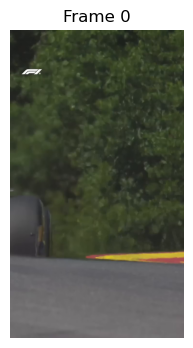

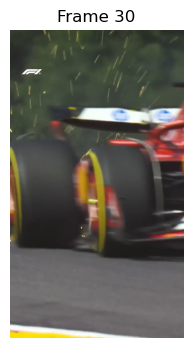

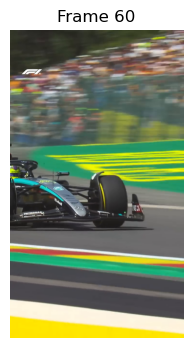

In [2]:
video_path = "video.mp4"

cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise RuntimeError(f"Cannot open {video_path}")

fps = cap.get(cv2.CAP_PROP_FPS)
W   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f"Resolution: {W}x{H}  FPS: {fps:.1f}")

for idx in [0, 30, 60]:
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    if ret:
        plt.figure(figsize=(6, 4))
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.title(f"Frame {idx}")
        plt.axis("off")
        plt.show()

cap.release()


## 2. Recursive mean background subtraction

Model: `B_t = (1 - alpha) * B_{t-1} + alpha * I_t`

In [3]:
alpha = 0.1

cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
bg = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(np.float32)

masks = []
while ret:
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    cv2.accumulateWeighted(gray, bg, alpha)
    diff = cv2.absdiff(gray, cv2.convertScaleAbs(bg))
    _, mask = cv2.threshold(diff, 25, 255, cv2.THRESH_BINARY)
    masks.append(mask)
    ret, frame = cap.read()

cap.release()
print(f"{len(masks)} frames processed")


853 frames processed


## 3. Test different alpha values

Small alpha: slow background update. Large alpha: fast, more responsive but noisier.

In [4]:
alpha_values = [0.01, 0.1, 0.5, 0.9]

for alpha in alpha_values:
    cap = cv2.VideoCapture(video_path)
    ret, frame = cap.read()
    bg = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(np.float32)

    out_path = f'moyenne_alpha_{alpha}.avi'
    out = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'XVID'), fps, (W, H), isColor=False)
    while True:
        ret, frame = cap.read()
        if not ret: break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        cv2.accumulateWeighted(gray, bg, alpha)
        diff = cv2.absdiff(gray, cv2.convertScaleAbs(bg))
        _, mask = cv2.threshold(diff, 25, 255, cv2.THRESH_BINARY)
        out.write(mask)
    cap.release()
    out.release()
    print(f"Saved: {out_path}")


Saved: moyenne_alpha_0.01.avi


Saved: moyenne_alpha_0.1.avi


Saved: moyenne_alpha_0.5.avi


Saved: moyenne_alpha_0.9.avi


## 4. Richefeu algorithm (morphological forgetting)

Per-pixel max `M_t` and min `m_t` envelopes. Motion detected where `M_t - m_t > delta`.

In [5]:
alpha = 0.1
delta_thr = 25

cap = cv2.VideoCapture(video_path)
ret, f0 = cap.read()
gray0 = cv2.cvtColor(f0, cv2.COLOR_BGR2GRAY).astype(np.float32)
Mt, mt = gray0.copy(), gray0.copy()
cap.release()

out = cv2.VideoWriter('richefeu_full.avi', cv2.VideoWriter_fourcc(*'XVID'), fps, (W, H), isColor=False)
cap = cv2.VideoCapture(video_path)
cap.read()
while True:
    ret, frame = cap.read()
    if not ret: break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(np.float32)
    Mt = alpha*gray + (1-alpha)*np.maximum(gray, Mt)
    mt = alpha*gray + (1-alpha)*np.minimum(gray, mt)
    _, mask = cv2.threshold(Mt - mt, delta_thr, 255, cv2.THRESH_BINARY)
    out.write(mask.astype(np.uint8))
cap.release()
out.release()
print('Saved: richefeu_full.avi')


Saved: richefeu_full.avi


## 5. Richefeu: vary threshold tau and morphological radius sigma

Morphological open+close applied with `cv2.morphologyEx` using an elliptical structuring element of radius sigma.

In [6]:
tau_values   = [10, 25, 50]
sigma_values = [1, 3, 5]

alpha = 0.1
cap = cv2.VideoCapture(video_path)
ret, f0 = cap.read()
gray0 = cv2.cvtColor(f0, cv2.COLOR_BGR2GRAY).astype(np.float32)
Mt, mt = gray0.copy(), gray0.copy()
gamma_list = []
while True:
    ret, frame = cap.read()
    if not ret: break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(np.float32)
    Mt = alpha*gray + (1-alpha)*np.maximum(gray, Mt)
    mt = alpha*gray + (1-alpha)*np.minimum(gray, mt)
    gamma_list.append(Mt - mt)
cap.release()

for tau in tau_values:
    for sigma in sigma_values:
        out_path = f'riche_tau{tau}_sigma{sigma}.avi'
        out = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'XVID'), fps, (W, H), isColor=False)
        se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*sigma+1, 2*sigma+1))
        for gamma in gamma_list:
            _, mask = cv2.threshold(gamma, tau, 255, cv2.THRESH_BINARY)
            m = mask.astype(np.uint8)
            cleaned = cv2.morphologyEx(cv2.morphologyEx(m, cv2.MORPH_OPEN, se), cv2.MORPH_CLOSE, se)
            out.write(cleaned)
        out.release()
        print(f"Saved: {out_path}")


Saved: riche_tau10_sigma1.avi


Saved: riche_tau10_sigma3.avi


Saved: riche_tau10_sigma5.avi


Saved: riche_tau25_sigma1.avi


Saved: riche_tau25_sigma3.avi


Saved: riche_tau25_sigma5.avi


Saved: riche_tau50_sigma1.avi


Saved: riche_tau50_sigma3.avi


Saved: riche_tau50_sigma5.avi


## 6. MOG2 background subtraction (Gaussian Mixture Model)

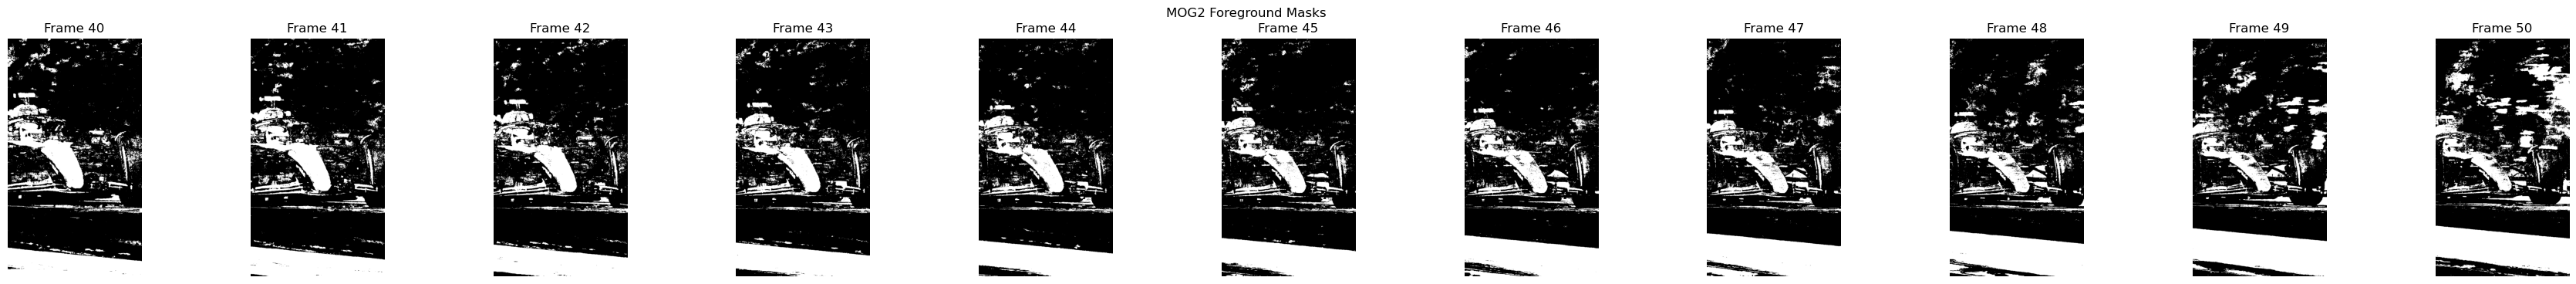

In [7]:
fgbg = cv2.createBackgroundSubtractorMOG2(history=500, varThreshold=16, detectShadows=False)

target_frames = set(range(40, 51))
stored = []
cap = cv2.VideoCapture(video_path)
idx = 0
while True:
    ret, frame = cap.read()
    if not ret: break
    mask = fgbg.apply(frame)
    if idx in target_frames:
        stored.append((idx, mask.copy()))
    idx += 1
cap.release()

fig, axes = plt.subplots(1, len(stored), figsize=(4*len(stored), 4))
for ax, (fi, m) in zip(axes, stored):
    ax.imshow(m, cmap="gray"); ax.set_title(f"Frame {fi}"); ax.axis("off")
plt.suptitle("MOG2 Foreground Masks")
plt.show()


## 7. Export full MOG2 mask video

In [8]:
fgbg2 = cv2.createBackgroundSubtractorMOG2(history=500, varThreshold=16, detectShadows=False)
out = cv2.VideoWriter('output_mog2_mask.avi', cv2.VideoWriter_fourcc(*'XVID'), fps, (W, H), isColor=False)
cap = cv2.VideoCapture(video_path)
n_frames = 0
while True:
    ret, frame = cap.read()
    if not ret: break
    out.write(fgbg2.apply(frame))
    n_frames += 1
cap.release()
out.release()
print(f"{n_frames} frames written to output_mog2_mask.avi")


853 frames written to output_mog2_mask.avi


## 8. Optical flow speed estimation (Farneback)

Per-pixel displacement between two consecutive frames, converted to an approximate speed map.

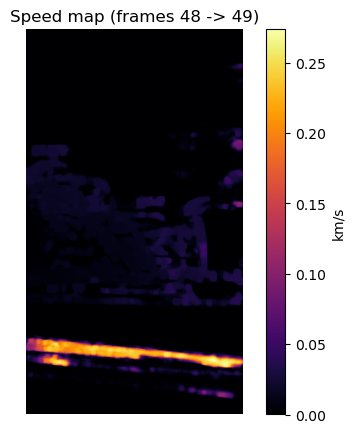

Mean speed: 0.01095 km/s


In [9]:
frame_index = 48
fps_video = 30.0
scale_m_per_pixel = 0.05

cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
_, frame1 = cap.read()
_, frame2 = cap.read()
cap.release()

gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

flow = cv2.calcOpticalFlowFarneback(
    gray1, gray2, None,
    pyr_scale=0.5, levels=3, winsize=15,
    iterations=3, poly_n=5, poly_sigma=1.2, flags=0
)

mag_km_s = np.sqrt(flow[...,0]**2 + flow[...,1]**2) * scale_m_per_pixel * fps_video / 1000.0

plt.figure(figsize=(6, 5))
plt.imshow(mag_km_s, cmap="inferno")
plt.colorbar(label="km/s")
plt.title(f"Speed map (frames {frame_index} -> {frame_index+1})")
plt.axis("off")
plt.show()
print(f"Mean speed: {np.mean(mag_km_s):.5f} km/s")
